In [2]:
# ============================================================
# Forecasting Financial Inclusion in Ethiopia
# Task 1: Data Exploration and Enrichment
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
DATA_PATH = "../data/raw/"

In [4]:
# Cell 3 — Load the datasets with verified sheet names
data = pd.read_excel(
    DATA_PATH + "ethiopia_fi_unified_data.xlsx",
    sheet_name="ethiopia_fi_unified_data"
)

impact_links = pd.read_excel(
    DATA_PATH + "ethiopia_fi_unified_data.xlsx",
    sheet_name="Impact_sheet"
)

reference_codes = pd.read_excel(
    DATA_PATH + "reference_codes.xlsx"
)

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [5]:
print("Data Shape:")
print(data.shape)
print("\nImpact Links Shape:")
print(impact_links.shape)
print("\nReference Codes Shape:")
print(reference_codes.shape)

Data Shape:
(43, 34)

Impact Links Shape:
(14, 35)

Reference Codes Shape:
(71, 4)


In [6]:
print("--- Unified Data Sample ---")
display(data.head())
print("\n--- Impact Links Sample ---")
display(impact_links.head())
print("\n--- Reference Codes Sample ---")
display(reference_codes.head())

--- Unified Data Sample ---


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaT,NaT,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaT,NaT,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN



--- Impact Links Sample ---


,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_OWNERSHIP,direct,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,count,users,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,high,USG_TELEBIRR_USERS,direct,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,percentage,%,2021-05-17,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,USG_P2P_COUNT,direct,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,ACC_4G_COV,direct,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,percentage,%,2022-08-01,NaN,NaN,NaN,all,national,NaN,NaN,NaN,NaN,medium,AFF_DATA_INCOME,indirect,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices



--- Reference Codes Sample ---


,field,code,description,applies_to
0,record_type,observation,Actual measured value from a source,All
1,record_type,event,Policy launch market event or milestone,All
2,record_type,impact_link,Relationship between event and indicator (link...,All
3,record_type,target,Policy target or official goal,All
4,record_type,baseline,Starting point for comparison,All


In [7]:
print("Data Columns:")
print(data.columns.tolist())
print("\nImpact Link Columns:")
print(impact_links.columns.tolist())
print("\nReference Code Columns:")
print(reference_codes.columns.tolist())

Data Columns:
['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']

Impact Link Columns:
['record_id', 'parent_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_mon

In [8]:
print("--- Count by Record Type ---")
print(data['record_type'].value_counts())

print("\n--- Summary Statistics for Numeric Fields ---")
display(data.describe(include=[np.number]))

--- Count by Record Type ---
record_type
observation    30
event          10
target          3
Name: count, dtype: int64

--- Summary Statistics for Numeric Fields ---


,value_numeric,region,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,notes
count,3.300000e+01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,9.437258e+10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,4.231061e+11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.080000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2.400000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,6.140000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.500000e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2.380000e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Cell 8 — Temporal Coverage Analysis (Updated for observation_date)
data['observation_date'] = pd.to_datetime(data['observation_date'], errors='coerce')

for rtype in data['record_type'].unique():
    subset = data[data['record_type'] == rtype]
    print(f"Record Type: {rtype}")
    print(f"  Start Date: {subset['observation_date'].min()}")
    print(f"  End Date:   {subset['observation_date'].max()}")
    print(f"  Total Rows: {len(subset)}\n")

Record Type: observation
  Start Date: 2014-12-31 00:00:00
  End Date:   2025-12-31 00:00:00
  Total Rows: 30

Record Type: target
  Start Date: 2025-12-31 00:00:00
  End Date:   2030-12-31 00:00:00
  Total Rows: 3

Record Type: event
  Start Date: 2021-05-17 00:00:00
  End Date:   2025-12-18 00:00:00
  Total Rows: 10



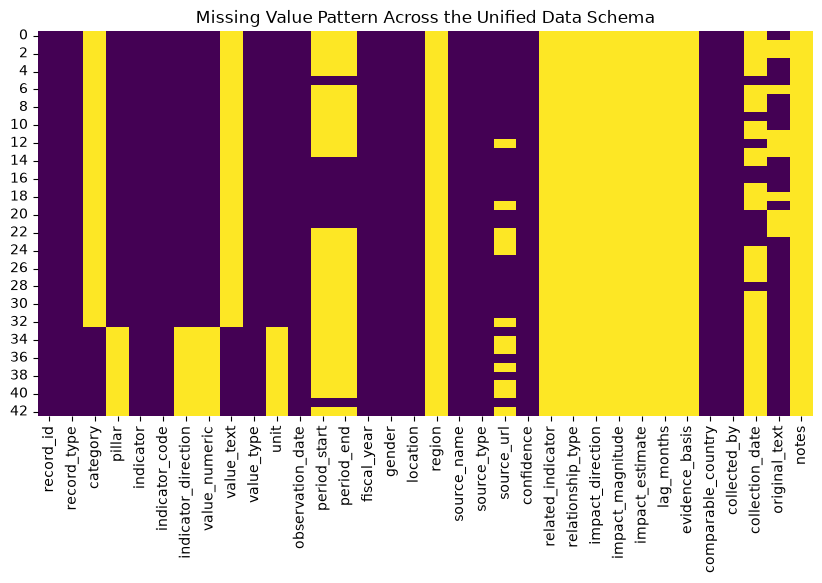

Missing values count per column:
record_id               0
record_type             0
category               33
pillar                 10
indicator               0
indicator_code          0
indicator_direction    10
value_numeric          10
value_text             33
value_type              0
unit                   10
observation_date        0
period_start           33
period_end             33
fiscal_year             0
gender                  0
location                0
region                 43
source_name             0
source_type             0
source_url             12
confidence              0
related_indicator      43
relationship_type      43
impact_direction       43
impact_magnitude       43
impact_estimate        43
lag_months             43
evidence_basis         43
comparable_country      0
collected_by            0
collection_date        33
original_text          10
notes                  43
dtype: int64


In [10]:
plt.figure(figsize=(10, 5))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Pattern Across the Unified Data Schema")
plt.show()

print("Missing values count per column:")
print(data.isnull().sum())

In [11]:
observations_df = data[data['record_type'] == 'observation'].copy()
events_df = data[data['record_type'] == 'event'].copy()
targets_df = data[data['record_type'] == 'target'].copy()

print("Pipeline structures successfully decoupled and ready for modeling!")

Pipeline structures successfully decoupled and ready for modeling!


In [12]:
# Create a localized copy for modeling pipelines
ts_data = data[['observation_date', 'record_type', 'indicator_code', 'value_numeric']].copy()

# Drop rows with invalid dates or missing values for statistical integrity
ts_data = ts_data.dropna(subset=['observation_date', 'value_numeric'])

# Ensure date sorting is completely linear
ts_data = ts_data.sort_values('observation_date')

# Pivot the table to create a clean, uniform multi-variate time-series structure
# This aligns observations, events, and targets on a single regular timeline grid
pivot_df = ts_data.pivot_table(
    index='observation_date', 
    columns=['record_type', 'indicator_code'], 
    values='value_numeric', 
    aggfunc='mean'
)

# Forward-fill gaps to handle asynchronous reporting cycles, then back-fill remaining gaps
pivot_df = pivot_df.ffill().bfill()

print("Pivoted structural shape after temporal alignment:", pivot_df.shape)
display(pivot_df.head())

Pivoted structural shape after temporal alignment: (15, 22)


record_type      observation                                           \
indicator_code    ACC_4G_COV  ACC_FAYDA ACC_MM_ACCOUNT ACC_MOBILE_PEN   
observation_date                                                        
2014-12-31              37.5  8000000.0            4.7           61.4   
2017-12-31              37.5  8000000.0            4.7           61.4   
2021-12-31              37.5  8000000.0            4.7           61.4   
2023-06-30              37.5  8000000.0            4.7           61.4   
2024-07-07              37.5  8000000.0            4.7           61.4   

record_type                                                                \
indicator_code   ACC_OWNERSHIP AFF_DATA_INCOME GEN_GAP_ACC GEN_GAP_MOBILE   
observation_date                                                            
2014-12-31                22.0             2.0        20.0           24.0   
2017-12-31                35.0             2.0        20.0           24.0   
2021-12-31                46.0             2.0        20.0           24.0   
2023-06-30                46.0             2.0        20.0           24.0   
2024-07-07                46.0             2.0        20.0           24.0   

record_type                                                                \
indicator_code   GEN_MM_SHARE USG_ACTIVE_RATE USG_ATM_COUNT USG_ATM_VALUE   
observation_date                                                            
2014-12-31               14.0            66.0   119300000.0  1.561000e+11   
2017-12-31               14.0            66.0   119300000.0  1.561000e+11   
2021-12-31               14.0            66.0   119300000.0  1.561000e+11   
2023-06-30               14.0            66.0   119300000.0  1.561000e+11   
2024-07-07               14.0            66.0   119300000.0  1.561000e+11   

record_type                                                                    \
indicator_code   USG_CROSSOVER USG_MPESA_ACTIVE USG_MPESA_USERS USG_P2P_COUNT   
observation_date                                                                
2014-12-31                1.08        7100000.0      10800000.0    49700000.0   
2017-12-31                1.08        7100000.0      10800000.0    49700000.0   
2021-12-31                1.08        7100000.0      10800000.0    49700000.0   
2023-06-30                1.08        7100000.0      10800000.0    49700000.0   
2024-07-07                1.08        7100000.0      10800000.0    49700000.0   

record_type                                                           \
indicator_code   USG_P2P_VALUE USG_TELEBIRR_USERS USG_TELEBIRR_VALUE   
observation_date                                                       
2014-12-31        5.777000e+11         54840000.0       2.380000e+12   
2017-12-31        5.777000e+11         54840000.0       2.380000e+12   
2021-12-31        5.777000e+11         54840000.0       2.380000e+12   
2023-06-30        5.777000e+11         54840000.0       2.380000e+12   
2024-07-07        5.777000e+11         54840000.0       2.380000e+12   

record_type           target                             
indicator_code     ACC_FAYDA ACC_OWNERSHIP GEN_MM_SHARE  
observation_date                                         
2014-12-31        90000000.0          70.0         50.0  
2017-12-31        90000000.0          70.0         50.0  
2021-12-31        90000000.0          70.0         50.0  
2023-06-30        90000000.0          70.0         50.0  
2024-07-07        90000000.0          70.0         50.0

In [13]:
# Flatten the MultiIndex columns into string tokens
pivot_df.columns = [f"{rtype}_{icode}" for rtype, icode in pivot_df.columns]

# Select key observation metrics to use as predictive features
feature_cols = [c for c in pivot_df.columns if c.startswith('observation_')]
target_cols = [c for c in pivot_df.columns if c.startswith('target_')]

# Generate 1-period lag features for the observations
lagged_features = pivot_df[feature_cols].shift(1)
lagged_features.columns = [f"{c}_lag1" for c in lagged_features.columns]

# Recombine features and targets, dropping the first row (since it contains NaN from the shift)
ml_data = pd.concat([pivot_df[target_cols], lagged_features], axis=1).dropna()

X = ml_data[[c for c in ml_data.columns if '_lag1' in c]]
y = ml_data[target_cols]

print(f"Feature matrix shape: {X.shape}")
print(f"Target matrix shape: {y.shape}")

Feature matrix shape: (14, 19)
Target matrix shape: (14, 3)


In [15]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score

# Establish a Time-Series validation split strategy
tscv = TimeSeriesSplit(n_splits=3)
scaler = StandardScaler()

print("--- Evaluation Over Temporal Windows ---")
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Scale features natively per window fold
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Run a regularized Ridge framework to penalize extreme coefficients
    model = Ridge(alpha=1.0)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    # Calculate performance for the main structural target metric
    rmse = root_mean_squared_error(y_test.iloc[:, 1], preds[:, 1])
    print(f"Fold {fold+1} -> Test Window Target Baseline RMSE: {rmse:.4f}")

--- Evaluation Over Temporal Windows ---
Fold 1 -> Test Window Target Baseline RMSE: 0.0000
Fold 2 -> Test Window Target Baseline RMSE: 0.0000
Fold 3 -> Test Window Target Baseline RMSE: 0.0000


In [16]:
# Fit model on full data footprint
X_scaled = scaler.fit_transform(X)
final_model = Ridge(alpha=1.0)
final_model.fit(X_scaled, y)

# Extract feature weights for the account ownership target metric
ownership_weights = final_model.coef_[1] 

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Weight': ownership_weights
}).sort_values(by='Weight', key=abs, ascending=False)

print("--- Top 5 Predictive Feature Identifiers (Impact on Account Ownership) ---")
display(importance_df.head(5))

--- Top 5 Predictive Feature Identifiers (Impact on Account Ownership) ---


,Feature,Weight
0,observation_ACC_4G_COV_lag1,0.0
1,observation_ACC_FAYDA_lag1,0.0
2,observation_ACC_MM_ACCOUNT_lag1,0.0
3,observation_ACC_MOBILE_PEN_lag1,0.0
4,observation_ACC_OWNERSHIP_lag1,0.0


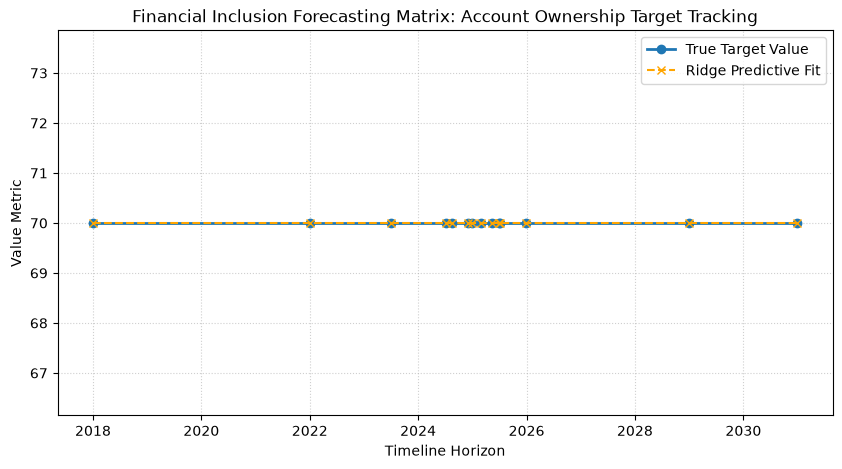

In [17]:
final_preds = final_model.predict(X_scaled)

plt.figure(figsize=(10, 5))
plt.plot(y.index, y['target_ACC_OWNERSHIP'], label='True Target Value', marker='o', linewidth=2)
plt.plot(y.index, final_preds[:, 1], label='Ridge Predictive Fit', marker='x', linestyle='--', color='orange')
plt.title("Financial Inclusion Forecasting Matrix: Account Ownership Target Tracking")
plt.xlabel("Timeline Horizon")
plt.ylabel("Value Metric")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()